In [1]:
import cv2
import numpy as np
import os

In [2]:
# 画像の読み込み
def load_image(image_path):
    """画像を読み込んでnumpy配列に変換する関数

    Args:
        image_path (str): 画像ファイルのパス(.pngまたは.jpg)

    Returns:
        np.ndarray: 読み込んだ画像のnumpy配列 (W, H, C)
    """
    # 画像の読み込み
    img = cv2.imread(image_path)

    # BGRからRGBに変換
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img.transpose(1, 0, 2)


def get_array_image_shape(image_dir: str):
    array_images_shape = np.array([])
    for file_name_image in os.listdir(image_dir):
        image_path = os.path.join(image_dir, file_name_image)
        array_image = load_image(image_path)

        array_shape = np.array(array_image.shape).reshape((1, 3))

        if array_images_shape.size == 0:
            array_images_shape = array_shape
        else:
            array_images_shape = np.concatenate([array_images_shape, array_shape])

    return array_images_shape


# 使用例
# image_path = "../data/dense/images/568.png"  # または "sample.png"
# img_array = load_image(image_path)
# print(f"画像の形状: {img_array.shape}")
# print(type(np.array(img_array.shape)))

images_dir = "../data/dense/images/"
array_shape = get_array_image_shape(images_dir)
array_shape.shape

(1714, 3)

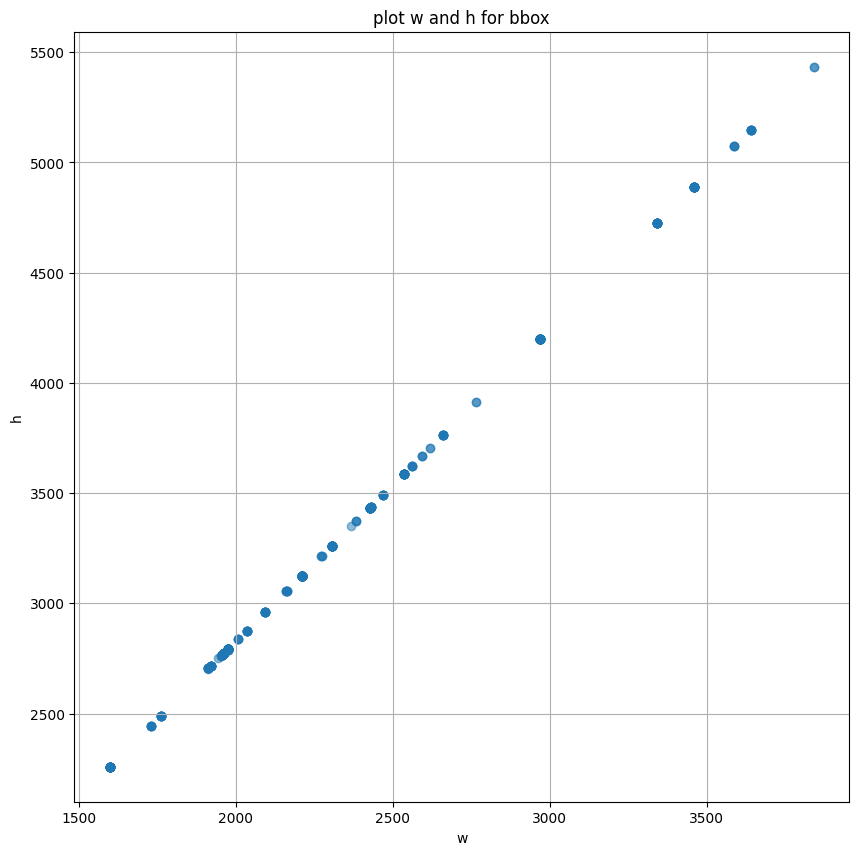

In [6]:
image_wh = array_shape[:, 0:2]
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(image_wh[:, 0], image_wh[:, 1], alpha=0.5)
plt.xlabel("w")
plt.ylabel("h")
plt.title("plot w and h for bbox")
plt.grid(True)
plt.show()

In [2]:
# ラベルの読み込み
def load_label(label_path: str, is_original: bool = True) -> np.ndarray:
    with open(label_path, "r") as file:
        lines = file.readlines()

    values = []
    for line in lines:
        if is_original:
            elements = line.strip().split(",")
            values.append([float(elements[0])] + [0] + [float(x) for x in elements[2:]])
        else:
            elements = line.strip().split(" ")
            values.append([float(x) for x in elements])
    values = np.array(values)

    return values


def label_convert_to_array(labels_dir: str, is_original: bool = True) -> np.ndarray:
    values = np.array([])
    for finelname_label in os.listdir(labels_dir):
        label_path = os.path.join(labels_dir, finelname_label)

        if values.size == 0:
            values = load_label(label_path, is_original)
        else:
            values = np.concatenate([values, load_label(label_path, is_original)])
    return values


labels_dir = "../data/dense/labels_mapping_to_center_and_normalization/"
# labels_dir = "../data/dense/labels/"
values = label_convert_to_array(labels_dir, is_original=False)
values.shape

(430533, 6)

In [3]:
# print(values[:, 1].max(), values[:, 1].min(), values[:, 1].argmax())
# print(values[:, 3].max())
# print(values[:, 3].argmax())
# print(values[79099])
print(values[:, :][0])
print(np.sort(np.unique(values[:, 0]))[-5:])
print(np.unique(values[:, 0]).shape)
print(values[:, 0:1][0])
print(values[:, 0:2][0])
print(values[:, 3:5][0])

[2.700e+01 1.000e+01 5.446e-01 3.653e-01 1.070e-02 6.100e-03]
[66. 67. 68. 69. 70.]
(20,)
[27.]
[27. 10.]
[0.3653 0.0107]


/tmp/ipykernel_89157/3299540921.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


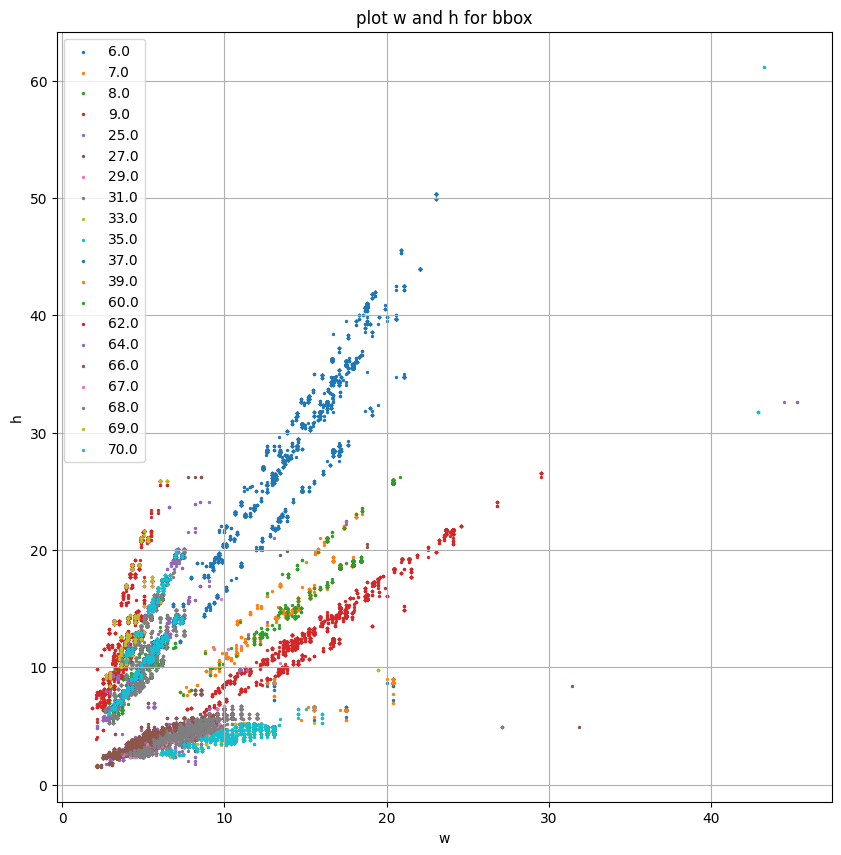

In [5]:
RESIZE_SIZE = 800
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for label_number in np.sort(np.unique(values[:, 0])):
    wh = values[values[:, 0] == label_number][:, 4:6]
    plt.scatter(
        wh[:, 0] * RESIZE_SIZE,
        wh[:, 1] * RESIZE_SIZE,
        alpha=1,
        s=2,
        cmap="tab20",
        label=label_number,
    )

# plt.xlim(0, 0.04)
# plt.ylim(0, 0.06)
plt.xlabel("w")
plt.ylabel("h")
plt.legend()
plt.title("plot w and h for bbox")
plt.grid(True)
plt.show()

In [42]:
# 正規化ができない画像の調査
image_number = 394
labels_dir = "../data/dense/labels/"
image_path = images_dir + f"{image_number}.png"
label_path = labels_dir + f"{image_number}.txt"
image = load_image(image_path)
label = load_label(label_path)

print("image size", image.shape)
print(label)
print("w max", label[:, 3].max())
print("h max", label[:, 4].max())

image size (1960, 2772, 3)
[[1.350e+02 9.300e+01 2.303e+03 1.866e+03 2.369e+03]
 [1.350e+02 9.300e+01 1.977e+03 1.856e+03 2.044e+03]
 [1.350e+02 9.300e+01 2.038e+03 1.856e+03 2.105e+03]
 ...
 [2.090e+02 1.280e+02 9.390e+02 2.559e+03 2.000e+00]
 [2.090e+02 1.280e+02 1.849e+03 2.558e+03 1.700e+01]
 [2.090e+02 1.290e+02 1.620e+03 2.557e+03 2.000e+00]]
w max 2559.0
h max 2698.0


In [30]:
for i in range(4):
    print((i + 2) % 2)

0
1
0
1


2